In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("D:\\career\\DOMAIN\hiver\\twcs.csv")   
print("Dataset shape:",df.shape)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\h'
C:\Users\harshan\AppData\Local\Temp\ipykernel_5076\1441158686.py:1: SyntaxWarning: invalid escape sequence '\h'
  df=pd.read_csv("D:\\career\\DOMAIN\hiver\\twcs.csv")


Dataset shape: (2811774, 7)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [3]:
print("Number of rows:",len(df))
print("Number of columns:",len(df.columns))
print("\nDataSet Info:")
df.info()

Number of rows: 2811774
Number of columns: 7

DataSet Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2811774 entries, 0 to 2811773
Data columns (total 7 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   tweet_id                 int64  
 1   author_id                object 
 2   inbound                  bool   
 3   created_at               object 
 4   text                     object 
 5   response_tweet_id        object 
 6   in_response_to_tweet_id  float64
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 131.4+ MB


In [4]:
print("Columns:")
for col in df.columns:
    print("-",col)
print("\nData types:")
print(df.dtypes)

Columns:
- tweet_id
- author_id
- inbound
- created_at
- text
- response_tweet_id
- in_response_to_tweet_id

Data types:
tweet_id                     int64
author_id                   object
inbound                       bool
created_at                  object
text                        object
response_tweet_id           object
in_response_to_tweet_id    float64
dtype: object


In [5]:
#checking null values in the dataset
missing=pd.DataFrame({
    "missing_count:":df.isnull().sum(),
    "missing_percent:":df.isnull().mean()*100
})
missing

,missing_count:,missing_percent:
tweet_id,0,0.000000
author_id,0,0.000000
inbound,0,0.000000
created_at,0,0.000000
text,0,0.000000
response_tweet_id,1040629,37.009696
in_response_to_tweet_id,794335,28.250315


In [6]:
print("Duplicated rows:",df.duplicated().sum())
print("Duplicated ids:" ,df["tweet_id"].duplicated().sum())

Duplicated rows: 0
Duplicated ids: 0


Therefore there are no duplicates in our dataset

In [7]:
print(df["inbound"].value_counts())

print("\nPercentage:")
print(df["inbound"].value_counts(normalize=True)* 100)  #normalizing gives you fraction of the categories in the dataset

inbound
True     1537843
False    1273931
Name: count, dtype: int64

Percentage:
inbound
True     54.69298
False    45.30702
Name: proportion, dtype: float64


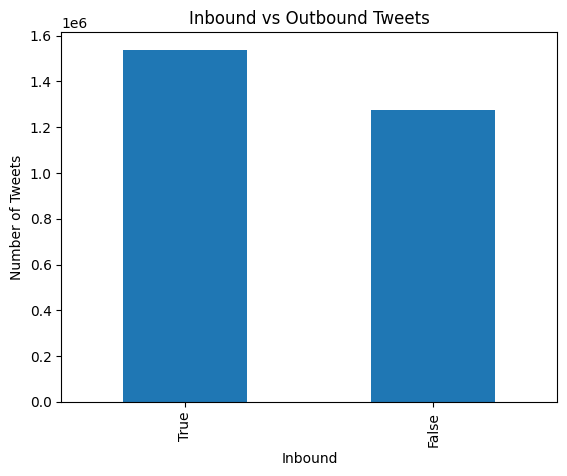

In [8]:
df["inbound"].value_counts().plot(kind="bar")

plt.title("Inbound vs Outbound Tweets")
plt.xlabel("Inbound")
plt.ylabel("Number of Tweets")
plt.show()

We can see that the customer tweets are higher and the reply tweets are lower

In [9]:
for _, row in df.head(10).iterrows():
    role = "CUSTOMER" if row["inbound"] else "BRAND"
    
    print(f"\n[{role}]")
    print(row["text"])
  


[BRAND]
@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.

[CUSTOMER]
@sprintcare and how do you propose we do that

[CUSTOMER]
@sprintcare I have sent several private messages and no one is responding as usual

[BRAND]
@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.

[CUSTOMER]
@sprintcare I did.

[BRAND]
@115712 Can you please send us a private message, so that I can gain further details about your account?

[CUSTOMER]
@sprintcare is the worst customer service

[BRAND]
@115713 This is saddening to hear. Please shoot us a DM, so that we can look into this for you. -KC

[CUSTOMER]
@sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯

[BRAND]
@115713 We understand your concerns and we'd like for you to please send us a Direct Message, so that we can further assist you. -AA


In [10]:
print("Unique authors:", df["author_id"].nunique())
df["author_id"].value_counts().head(20)

Unique authors: 702777


author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
SpotifyCares        43265
Delta               42253
Tesco               38573
AmericanAir         36764
TMobileHelp         34317
comcastcares        33031
British_Airways     29361
SouthwestAir        28977
VirginTrains        27817
Ask_Spectrum        25860
XboxSupport         24557
sprintcare          22381
hulu_support        21872
sainsburys          19466
GWRHelp             19364
AskPlayStation      19098
ChipotleTweets      18749
Name: count, dtype: int64

In [11]:
df["text_length"] = df["text"].fillna("").str.len()

print(df["text_length"].describe())

count    2.811774e+06
mean     1.138897e+02
std      5.234562e+01
min      1.000000e+00
25%      7.800000e+01
50%      1.150000e+02
75%      1.390000e+02
max      5.130000e+02
Name: text_length, dtype: float64


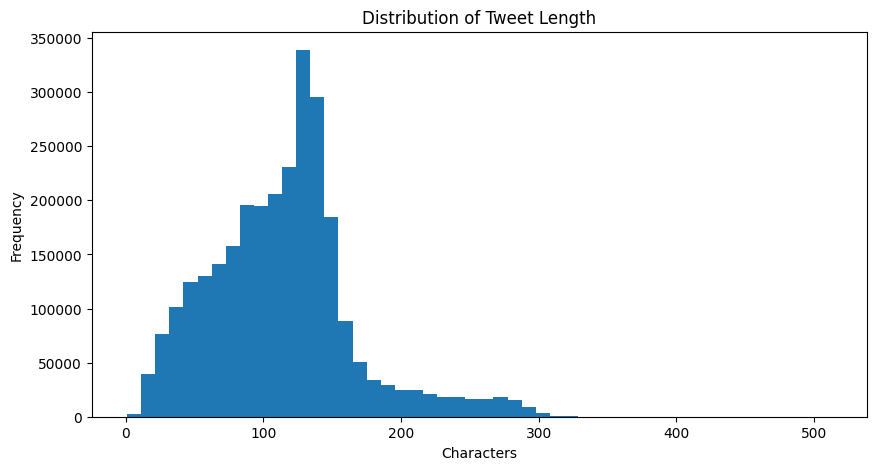

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(df["text_length"], bins=50)

plt.title("Distribution of Tweet Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

We can see that most of the tweet length falls between 100 to 200 characters

Let check the shorter and longer messages

In [13]:
df.sort_values("text_length").head(10)[
    ["inbound", "text", "text_length"]
]

,inbound,text,text_length
1445676,True,I,1
1984240,True,I,1
1842610,True,?,1
2342740,True,I,1
2220503,True,🍺,1
2040583,True,I️,2
1483046,True,i️,2
1538622,True,I️,2
1557660,True,I️,2
1975697,True,i️,2


In [14]:
df.sort_values("text_length", ascending=False).head(10)[
    ["inbound", "text", "text_length"]
]

,inbound,text,text_length
217042,True,@176042 @176031 @176045 @176044 @176047 @17604...,513
191819,True,@169917 @426 @427 @81 @169918 @169919 @160959 ...,507
1969278,True,@625926 @comcastcares @116136 @115900 @359957 ...,495
2806152,True,@822576 @822573 @822580 @822583 @822584 @82257...,493
2806139,True,@822577 @822576 @822578 @822579 @822580 @82258...,490
191797,True,@169917 @426 @427 @81 @169918 @169919 @160959 ...,489
2806181,True,@822578 @822583 @822575 @822577 @822588 @82258...,481
472108,True,@243918 @243919 @243920 @243921 @243922 @24392...,476
1969277,True,@625926 @comcastcares @116136 @115900 @359957 ...,472
2806212,True,@822589 @822575 @822573 @822574 @822583 @82258...,469


In [15]:
print(
    "Tweets replying to another tweet:",
    df["in_response_to_tweet_id"].notna().sum()
)

print(
    "Tweets with a response:",
    df["response_tweet_id"].notna().sum()
)

Tweets replying to another tweet: 2017439
Tweets with a response: 1771145


In [16]:
print("Missing relationship information:")
print(df[
    ["response_tweet_id", "in_response_to_tweet_id"]
].isnull().sum())

Missing relationship information:
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64


In [17]:
df[df["in_response_to_tweet_id"].notna()][[
    "tweet_id",
    "inbound",
    "text",
    "in_response_to_tweet_id"
]].head(10)

,tweet_id,inbound,text,in_response_to_tweet_id
0,1,False,@115712 I understand. I would like to assist y...,3.0
1,2,True,@sprintcare and how do you propose we do that,1.0
2,3,True,@sprintcare I have sent several private messag...,4.0
3,4,False,@115712 Please send us a Private Message so th...,5.0
4,5,True,@sprintcare I did.,6.0
5,6,False,@115712 Can you please send us a private messa...,8.0
7,11,False,@115713 This is saddening to hear. Please shoo...,12.0
8,12,True,@sprintcare You gonna magically change your co...,15.0
9,15,False,@115713 We understand your concerns and we'd l...,16.0
10,16,True,@sprintcare Since I signed up with you....Sinc...,17.0


In [18]:
# Creating a lookup for the tweets
tweet_lookup = df.set_index("tweet_id")["text"]

# For each tweet we find the text of the tweet it responds to
df["question_text"] = df["in_response_to_tweet_id"].map(tweet_lookup)

conversation_pairs = df[
    df["in_response_to_tweet_id"].notna()
][[
    "question_text",
    "text",
    "inbound"
]]

for i, row in df.head(10)[["question_text", "text", "inbound"]].iterrows():
    role = "CUSTOMER" if row["inbound"] else "BRAND"
    print(f"\nRow {i}")
    print("Question:", row["question_text"])
    print("Response:", row["text"])
    print(role)
    print("-" * 80)


Row 0
Question: @sprintcare I have sent several private messages and no one is responding as usual
Response: @115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.
BRAND
--------------------------------------------------------------------------------

Row 1
Question: @115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.
Response: @sprintcare and how do you propose we do that
CUSTOMER
--------------------------------------------------------------------------------

Row 2
Question: @115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.
Response: @sprintcare I have sent several private messages and no one is responding as usual
CUSTOMER
--------------------------------------------------------------------------------

Row 3
Question: @sprintcare I did.
Response: @115712 Please send us a 

we see the actual conversation of the customer 115713 and the brand "sprintcare"

In [19]:
df.head(2)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,text_length,question_text
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0,121,@sprintcare I have sent several private messag...
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0,45,@115712 I understand. I would like to assist y...


Now our dataframe contains a question along side its response

Now we gotta choose a brand

In [20]:
df.groupby(["author_id", "inbound"]).size().unstack(fill_value=0).sort_values(
    by=False, ascending=False
).head(10)

inbound,False,True
author_id,,
AmazonHelp,169840,0
AppleSupport,106860,0
Uber_Support,56270,0
SpotifyCares,43265,0
Delta,42253,0
Tesco,38573,0
AmericanAir,36764,0
TMobileHelp,34317,0
comcastcares,33031,0


In [21]:
responses = df[         #it keeps only actual responses
    df["question_text"].notna() &
    (df["inbound"] == False)
]

In [22]:
response_counts = responses["author_id"].value_counts()

print(response_counts.head(10))

author_id
AmazonHelp         168823
AppleSupport       106648
Uber_Support        56193
SpotifyCares        43206
Delta               42149
Tesco               38470
AmericanAir         36531
TMobileHelp         34229
comcastcares        32975
British_Airways     29291
Name: count, dtype: int64


AmazonHelp has more responses ,lets go with that

In [23]:
amazon = df[df["author_id"] == "AmazonHelp"]

print("AmazonHelp tweets:", len(amazon))


AmazonHelp tweets: 169840


In [24]:
print(
    "Customer tweets:",
    (amazon["inbound"] == True).sum()
)

print(
    "Brand responses:",
    (amazon["inbound"] == False).sum()
)

Customer tweets: 0
Brand responses: 169840


In [25]:
amazon_customers = df[
    (df["inbound"] == True) &
    (df["text"].str.contains("@AmazonHelp", case=False, na=False))
]

print(amazon_customers.shape)
amazon_customers.head()

(135160, 9)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,text_length,question_text
182,270,115770,True,Wed Nov 22 09:24:30 +0000 2017,@AmazonHelp ありがとうございます。\n今、電話で主人が対応していただいてます。,NaN,269.0,44,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは...
183,271,115770,True,Wed Nov 22 09:30:36 +0000 2017,@AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎ...,273,269.0,63,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは...
185,274,115770,True,Wed Nov 22 09:44:04 +0000 2017,@AmazonHelp こちらこそありがとうございました。,275,273.0,29,@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました...
322,616,115820,True,Tue Oct 31 23:22:08 +0000 2017,@AmazonHelp 3 different people have given 3 di...,618,615.0,147,@115820 I'm sorry we've let you down! Without ...
324,619,115820,True,Tue Oct 31 23:32:26 +0000 2017,@AmazonHelp I frankly don't have the patience ...,NaN,618.0,105,@115820 We'd like to take a further look into ...


In [26]:
for text in amazon_customers["text"].head(20):
    print(text)
    print("-" * 80)

@AmazonHelp ありがとうございます。
今、電話で主人が対応していただいてます。
--------------------------------------------------------------------------------
@AmazonHelp 電話で対応してもらいましたが改良されませんでした。
保証期間も過ぎてるので買い直しになるんでしょうね。
--------------------------------------------------------------------------------
@AmazonHelp こちらこそありがとうございました。
--------------------------------------------------------------------------------
@AmazonHelp 3 different people have given 3 different answers and I still don't have my order. Says delivered Saturday, was not, I was home all day
--------------------------------------------------------------------------------
@AmazonHelp I frankly don't have the patience for another chat with your "customer service" people today.
--------------------------------------------------------------------------------
@AmazonHelp Okay, danke für die Info
--------------------------------------------------------------------------------
@AmazonHelp @115826 Yeah this is crazy we’re less than a week away and still no Ship

There are some other languages mixed in the responses ,lets detect those

In [27]:
amazon_responses = responses[
    responses["author_id"] == "AmazonHelp"
].copy()

print("Amazon responses:", len(amazon_responses))

Amazon responses: 168823


In [28]:
#we just have to check the languages in amazon_responses not the entire responses
from langdetect import detect

def detect_language(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

test = amazon_responses.head(1000).copy()

test["language"] = test["text"].apply(detect_language)

print(test["language"].value_counts())

language
en         875
ja          73
es          19
de          11
pt           9
fr           4
so           2
it           2
vi           1
af           1
da           1
cy           1
unknown      1
Name: count, dtype: int64


since Amazon help has approximately 88% of english responses,lets use that to build a prototype that focuses on english-language support

In [29]:
#Lets pair the brand questions and the responses
amazon_pairs = responses[
    responses["author_id"] == "AmazonHelp"
][[
    "question_text",
    "text"
]].copy()

amazon_pairs.columns = [
    "customer_message",
    "amazon_response"
]

print(amazon_pairs.shape)
amazon_pairs.head()

(168823, 2)


,customer_message,amazon_response
181,amazonのfireTVstickが見れない😢,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは...
184,@AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎ...,@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました...
186,@AmazonHelp こちらこそありがとうございました。,@115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお...
234,amazonプライムビデオ、再生エラーが多いです,@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の...
321,Way to drop the ball on customer service @1158...,@115820 I'm sorry we've let you down! Without ...


In [30]:
#lets see what the conversations are like
for _, row in amazon_pairs.head(10).iterrows(): #alter the head to check more,i lowered it for readability

    print("\nCUSTOMER:")
    print(row["customer_message"])

    print("\nAMAZON:")
    print(row["amazon_response"])

    print("="*100)


CUSTOMER:
amazonのfireTVstickが見れない😢

AMAZON:
@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET

CUSTOMER:
@AmazonHelp 電話で対応してもらいましたが改良されませんでした。
保証期間も過ぎてるので買い直しになるんでしょうね。

AMAZON:
@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました。リプライいただきありがとうございました。ET

CUSTOMER:
@AmazonHelp こちらこそありがとうございました。

AMAZON:
@115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお願いします。ET

CUSTOMER:
amazonプライムビデオ、再生エラーが多いです

AMAZON:
@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の再起動にて改善する場合がございますので、お試しください。改善しない場合は、状況を確認しご案内させていただきますのでこちらからカスタマーサービスまでご連絡ください。https://t.co/NtNAX2Qh2u ET

CUSTOMER:
Way to drop the ball on customer service @115821 so pissed right now!

AMAZON:
@115820 I'm sorry we've let you down! Without providing any personal information, will you describe the issue? We'd love to help. ^TN

CUSTOMER:
@AmazonHelp 3 different people have given 3 different answers and I still don't have my order. Says delivered Saturday, was not, I was 

Before classifing these messages into intends,
We are gonna decide what intends should we assign by inspecting a sample

In [31]:
amazon_sample = amazon_pairs.sample(
    n=500,
    random_state=42
)

In [32]:
#lets label them 
label_df = amazon_pairs.sample(
    n=500,
    random_state=42
).copy()

label_df["intent"] = ""

In [33]:
def label_messages(df):
    print(f"Dataset contains {len(df)} rows")

    start = int(input("Enter START position: "))
    end = int(input("Enter END position (exclusive): "))

    if start < 0 or end > len(df) or start >= end:
        print("Invalid range.")
        return

    print("\nType an intent to label.")
    print("Press ENTER to leave unlabeled.")
    print("Type 'q' to quit.\n")

    for position in range(start, end):

        idx = df.index[position]
        row = df.iloc[position]

        print("\n" + "=" * 100)
        print(f"POSITION: {position}")
        print(f"INDEX: {idx}")

        print("\nCUSTOMER:")
        print(row["customer_message"])

        print("\nAMAZON:")
        print(row["amazon_response"])

        print("\nCurrent intent:", row["intent"])

        label = input("\nEnter intent: ").strip()

        if label.lower() == "q":
            print("\nStopped labeling.")
            break

        if label == "":
            print("Skipped.")
            continue

        df.loc[idx, "intent"] = label

        print(f"✓ Labeled as: {label}")

    print("\nLabeling session finished.")

In [42]:
print(label_df.columns.tolist())

['customer_message', 'amazon_response', 'intent']


In [35]:
#we are gonna do some manual labelling work
# label_messages(label_df)

In [45]:
label_df["intent"].value_counts()

intent
                                     427
Delivery / Tracking                   29
Other / General Inquiry               15
Technical / Website / App              8
Returns / Refunds                      7
Product Issue                          5
Gift Card                              3
Order Cancellation / Modification      2
Promotions / Discounts                 2
Prime Membership                       2
Name: count, dtype: int64

In [37]:
#normalizing some intents
label_df["intent"] = label_df["intent"].replace({
    "Other / General Inquiry":"Other/General Inquiry",
    "Product complaint": "Product Issue"
})

In [49]:
#after normalization of the intents
label_df["intent"].value_counts()

intent
                                     427
Delivery / Tracking                   29
Other / General Inquiry               15
Technical / Website / App              8
Returns / Refunds                      7
Product Issue                          5
Gift Card                              3
Order Cancellation / Modification      2
Promotions / Discounts                 2
Prime Membership                       2
Name: count, dtype: int64

In [41]:
#more labelling :(
label_messages(label_df)


Dataset contains 500 rows

Type an intent to label.
Press ENTER to leave unlabeled.
Type 'q' to quit.


POSITION: 150
INDEX: 2739243

CUSTOMER:
@AmazonHelp Claro, cancelé Amazon Prime pero me llegó el cargo de la membresía a mi tarjeta

AMAZON:
@806792 Lamento los inconvenientes. Recomiendo entrar en contacto directamente con nuestro Servicio al Cliente, para que verifiquen lo ocurrido: https://t.co/beR78zMMYB ^CR

Current intent: 
Skipped.

POSITION: 151
INDEX: 1350599

CUSTOMER:
@14045 @115850

No information about cashback on order Id 405-5491973-6941950 neither getting any way to connect
#FakeOffer

AMAZON:
@352397 I get how you feel, I'd like to look into this, please fill this form: https://t.co/beaaDm0muc and I’ll contact you soon. 1/2^SC

Current intent: 
✓ Labeled as: Returns / Refunds

POSITION: 152
INDEX: 2219801

CUSTOMER:
@AmazonHelp Yes, already checked and replied.

AMAZON:
@665264 Thanks for writing back on the issue. We are reviewing the situation. We shall reach out a

In [51]:
intent_counts = label_df.loc[
    label_df["intent"].str.strip() != "",
    "intent"
].value_counts()

intent_percent = (
    intent_counts / intent_counts.sum() * 100
).round(2)

summary = pd.DataFrame({
    "count": intent_counts,
    "percentage": intent_percent
})

print(summary)

                                   count  percentage
intent                                              
Delivery / Tracking                   29       39.73
Other / General Inquiry               15       20.55
Technical / Website / App              8       10.96
Returns / Refunds                      7        9.59
Product Issue                          5        6.85
Gift Card                              3        4.11
Order Cancellation / Modification      2        2.74
Promotions / Discounts                 2        2.74
Prime Membership                       2        2.74


In [53]:
label_df.head(1)

,customer_message,amazon_response,intent
1744101,Yo necesitaba elevar el espejo de mi tocador y...,"@565800 Hola, Aranzazu. ¡Una solución intelige...",


In [55]:
labeled_df = label_df[
    label_df["intent"].fillna("").str.strip() != ""
].copy()

print("Labeled examples:", len(labeled_df))
print(labeled_df["intent"].value_counts())

Labeled examples: 73
intent
Delivery / Tracking                  29
Other / General Inquiry              15
Technical / Website / App             8
Returns / Refunds                     7
Product Issue                         5
Gift Card                             3
Order Cancellation / Modification     2
Promotions / Discounts                2
Prime Membership                      2
Name: count, dtype: int64


In [56]:
#removing expressions etc for classification
import re

def clean_text(text):
    text = str(text)

    # Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

labeled_df["clean_message"] = (
    labeled_df["customer_message"]
    .apply(clean_text)
)

In [57]:
labeled_df[
    ["customer_message", "clean_message", "intent"]
].head(10)

,customer_message,clean_message,intent
1532918,@AmazonHelp @115850 mentioned in the mail like...,mentioned in the mail like I'll get back my mo...,Returns / Refunds
2150656,@115851 @AmazonHelp @115821 @115830 https://t....,,Delivery / Tracking
2119869,"@AmazonHelp I have shared the details. Now, pl...","I have shared the details. Now, please do some...",Delivery / Tracking
1543526,@115821 absolutely shocking ordered two weeks ...,absolutely shocking ordered two weeks ago noth...,Delivery / Tracking
2085534,@AmazonHelp Had to wait for 24hrs before they ...,Had to wait for 24hrs before they could do any...,Delivery / Tracking
365930,"@115850 dear Amazon plz look into this , I hav...","dear Amazon plz look into this , I haven’t rec...",Delivery / Tracking
2809100,I need assistance for amazon Cashback @AmazonHelp,I need assistance for amazon Cashback,Returns / Refunds
2713339,"@AmazonHelp Hi, they told me to wait for dispa...","Hi, they told me to wait for dispatch and retu...",Delivery / Tracking
1453974,"wow, amazon charged me for this prime thingy l...","wow, amazon charged me for this prime thingy l...",Delivery / Tracking
2655106,So much for a discount !! Selling pirated copy...,So much for a discount !! Selling pirated copy...,Product Issue


In [58]:
from sklearn.model_selection import train_test_split

X = labeled_df["clean_message"]
y = labeled_df["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
# Show the intent distribution
print("\nIntent distribution:")
print(labeled_df["intent"].value_counts())


Intent distribution:
intent
Delivery / Tracking                  29
Other / General Inquiry              15
Technical / Website / App             8
Returns / Refunds                     7
Product Issue                         5
Gift Card                             3
Order Cancellation / Modification     2
Promotions / Discounts                2
Prime Membership                      2
Name: count, dtype: int64


In [61]:
print("Examples:", len(labeled_df))
print("Intents:", labeled_df["intent"].nunique())

print("\nDistribution:")
print(labeled_df["intent"].value_counts())

Examples: 73
Intents: 9

Distribution:
intent
Delivery / Tracking                  29
Other / General Inquiry              15
Technical / Website / App             8
Returns / Refunds                     7
Product Issue                         5
Gift Card                             3
Order Cancellation / Modification     2
Promotions / Discounts                2
Prime Membership                      2
Name: count, dtype: int64


In [62]:
from collections import Counter

intent_counts = labeled_df["intent"].value_counts()

print("Intent distribution:")
print(intent_counts)

print("\nIntents with fewer than 5 examples:")
print(intent_counts[intent_counts < 5])

Intent distribution:
intent
Delivery / Tracking                  29
Other / General Inquiry              15
Technical / Website / App             8
Returns / Refunds                     7
Product Issue                         5
Gift Card                             3
Order Cancellation / Modification     2
Promotions / Discounts                2
Prime Membership                      2
Name: count, dtype: int64

Intents with fewer than 5 examples:
intent
Gift Card                            3
Order Cancellation / Modification    2
Promotions / Discounts               2
Prime Membership                     2
Name: count, dtype: int64


In [68]:
df.columns.tolist()

['tweet_id',
 'author_id',
 'inbound',
 'created_at',
 'text',
 'response_tweet_id',
 'in_response_to_tweet_id',
 'text_length',
 'question_text']

In [69]:
print("Amazon pairs saved:", amazon_pairs.shape)
print("Labeled data saved:", label_df.shape)

Amazon pairs saved: (168823, 2)
Labeled data saved: (500, 3)


In [70]:
#exprot the amazon dataset and label them using groq
amazon_pairs.to_csv("amazon_pairs.csv", index=False)